## Step 1: Install dependencies

In [ ]:
# Step 1: Install dependencies
!pip install shap xgboost scikit-learn pandas matplotlib seaborn -q


## Step 2: Import libraries

In [ ]:
# Step 2: Import libraries
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

shap.initjs()


## Exercise_1: Abalone Dataset — Materials / Metrology (Regression)

### Data

In [55]:
url = "https://raw.githubusercontent.com/iqram20/ComputerAidedAnalysis/main/resources/Week_7/abalone.csv"
df = pd.read_csv(url, header=None)

print("Shape:", df.shape)
df.head()


Shape: (4177, 9)


,0,1,2,3,4,5,6,7,8
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


### Feature Naming

In [56]:
# Step 2: Add column names for better readability
column_names = [
    "Sex", "Length", "Diameter", "Height",
    "WholeWeight", "ShuckedWeight", "VisceraWeight",
    "ShellWeight", "Rings"
]
df.columns = column_names


### Data Preprocessing

In [57]:
# Step 3: Encode 'Sex' to numeric (for modeling later)
df["Sex"] = df["Sex"].map({"M": 0, "F": 1, "I": 2})


### Feature Scatterplots

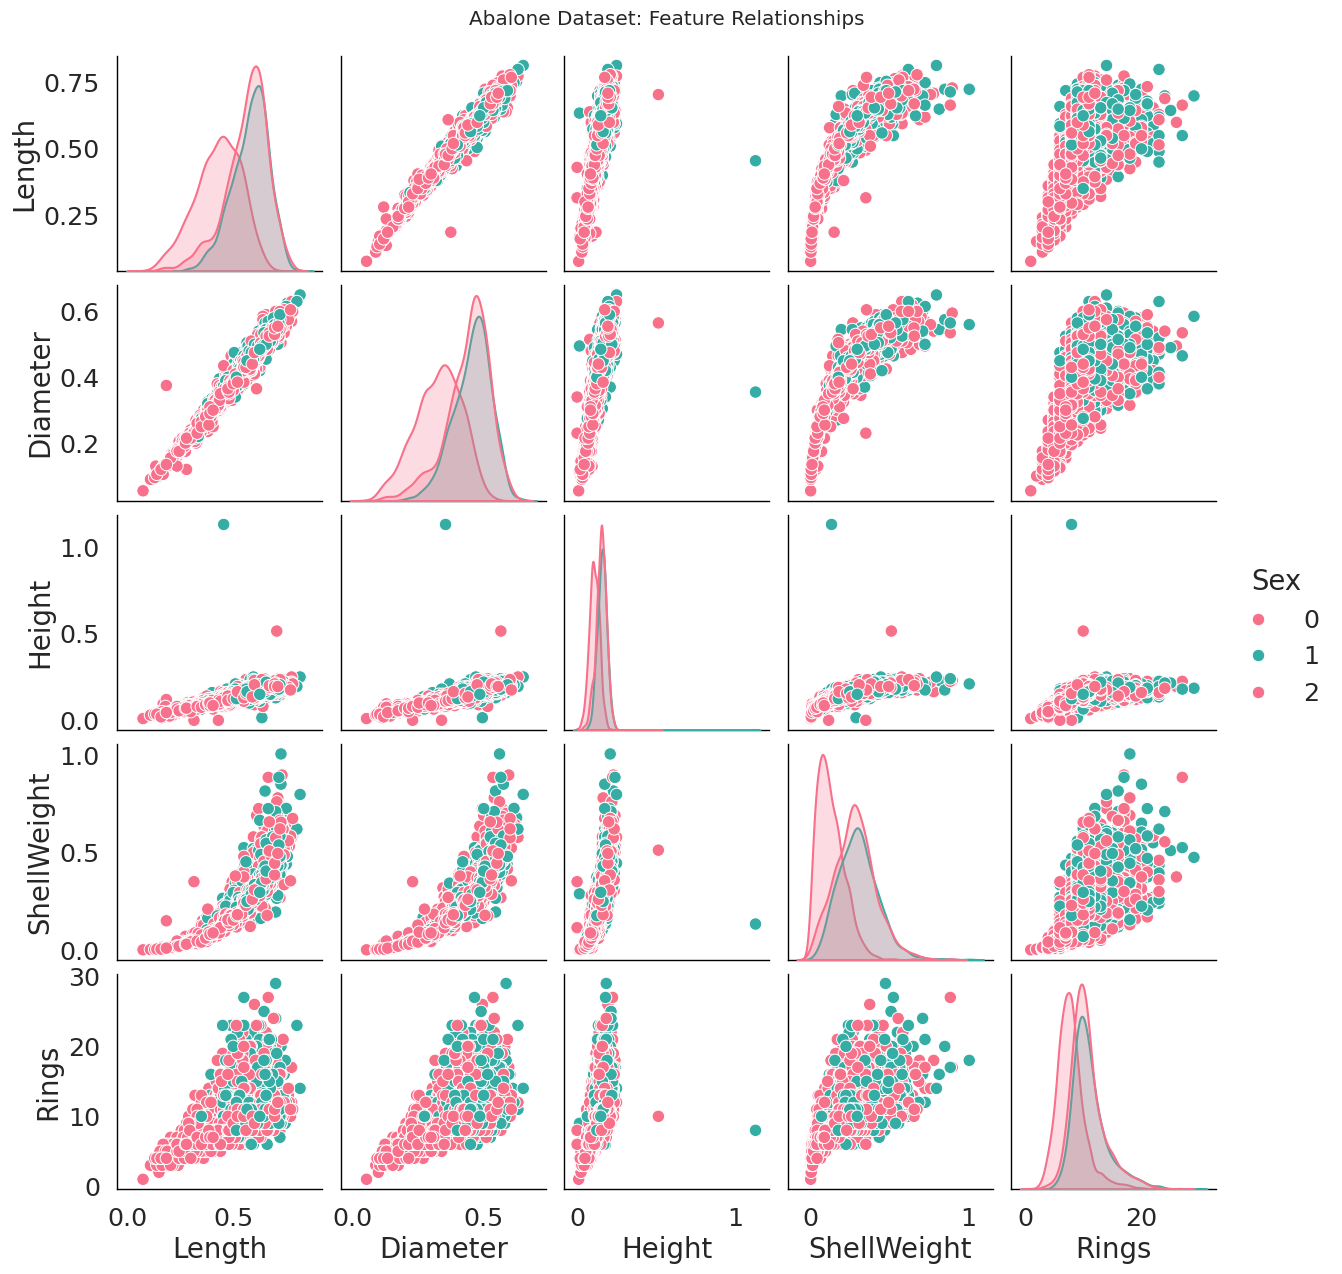

In [58]:
sns.pairplot(
    df,
    vars=["Length", "Diameter", "Height", "ShellWeight", "Rings"],
    hue="Sex",
    palette="husl",
    diag_kind="kde"
)
plt.suptitle("Abalone Dataset: Feature Relationships", y=1.02)
plt.show()


### Class Defination and Data Partition

In [59]:
# Step 2: Prepare data


X = df.iloc[:, :-1]
y = df.iloc[:, -1]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


### Model Training and Testing

In [60]:
# Step 3: Train model
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R²:", r2_score(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))


R²: 0.4989660978317261
MSE: 5.423796653747559


### Explaiable Machine Learning (SHAP)

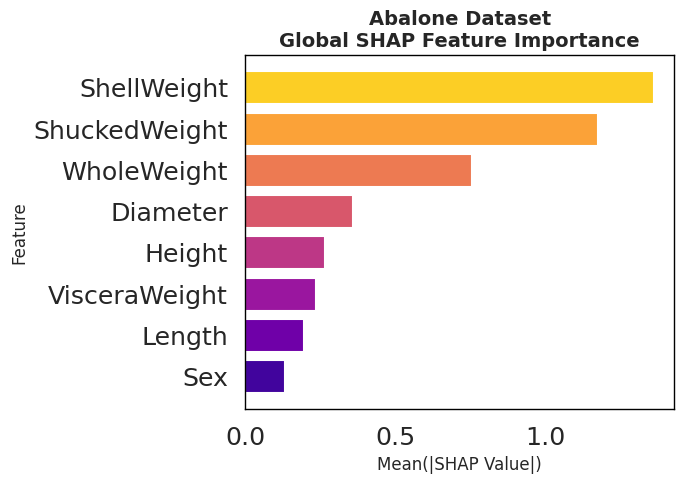

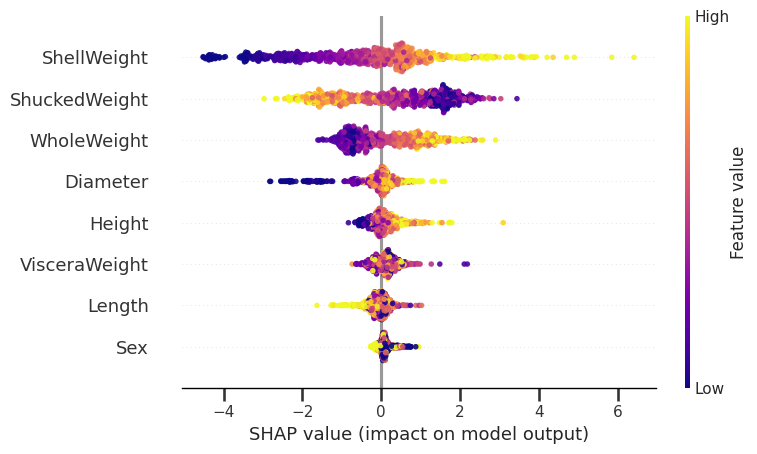

In [61]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_shap_nature(model, X, title_prefix):
    shap.initjs()
    sns.set_style("white")
    plt.rcParams.update({
        "font.size": 12,
        "axes.edgecolor": "black",
        "axes.linewidth": 1,
        "axes.facecolor": "white",
        "figure.facecolor": "white"
    })

    # Compute SHAP values
    explainer = shap.Explainer(model)
    shap_values = explainer(X)

    # --- 1️⃣ Global Feature Importance (Bar) ---
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    feature_names = (
        X.columns if hasattr(X, "columns") else [f"Feature {i}" for i in range(X.shape[1])]
    )
    sorted_idx = np.argsort(mean_abs_shap)[::-1]

    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(feature_names)))

    plt.figure(figsize=(7, 5))
    plt.barh(
        np.array(feature_names)[sorted_idx],
        mean_abs_shap[sorted_idx],
        color=colors[::-1]
    )
    plt.xlabel("Mean(|SHAP Value|)", fontsize=12)
    plt.ylabel("Feature", fontsize=12)
    plt.title(f"{title_prefix}\nGlobal SHAP Feature Importance", fontsize=14, weight="bold")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # --- Add a small visual gap before next plot ---
    plt.close()
    plt.figure(figsize=(0.01, 0.01))
    plt.axis("off")
    plt.show()

    # --- 2️⃣ Beeswarm Plot (Feature Impacts) ---
    shap.summary_plot(
        shap_values,
        X,
        cmap="plasma",
        alpha=0.9,
        show=True
    )

plot_shap_nature(model, X_test, "Abalone Dataset")
